# GULP Tutorial — Atomistic Modelling of Carbonate Minerals
### Geochemical Modelling Course · Universidad del Norte

**Based on:** Gale, J.D. (2011) *EPJ Web of Conferences* **14**, 03005
**Software:** GULP 6 — General Utility Lattice Program (Julian Gale, Curtin University)
**Cluster:** `granado.uninorte.edu.co`

---

## How this notebook works

| Step | Where | What you do |
|------|-------|-------------|
| 1 | **Here (notebook)** | Read background, examine input files |
| 2 | **Cluster** | Upload `.gin` files, run GULP, download `.gout` files |
| 3 | **Here (notebook)** | Run the analysis cells to parse results and make plots |

The GULP input files are displayed as code blocks below — copy each one,
save it as the indicated filename, and upload it to the cluster before each exercise.

---

## Minerals studied

| Mineral | Formula | Space group | Ca | Mg |
|---------|---------|-------------|----|----|
| Calcite | CaCO₃ | R$\overline{3}$c | ✓ | — |
| Magnesite | MgCO₃ | R$\overline{3}$c | — | ✓ |
| Dolomite | CaMg(CO₃)₂ | R$\overline{3}$ | ✓ | ✓ |

All three are **rhombohedral carbonates** — comparing them isolates the effect
of Ca²⁺ → Mg²⁺ substitution and ordered cation mixing (dolomite).

---
## 1 · Crystal Structures

Calcite and magnesite share the **calcite structure type** (space group R$\overline{3}$c):
alternating layers of M²⁺ cations (in octahedral coordination) and planar CO₃²⁻ groups
stacked along the *c*-axis.

Dolomite has the **dolomite structure** (R$\overline{3}$): the same layered arrangement
but with Ca²⁺ and Mg²⁺ layers alternating in an ordered fashion — every other
cation layer swaps from Ca to Mg.

Run the cell below to see schematic diagrams.

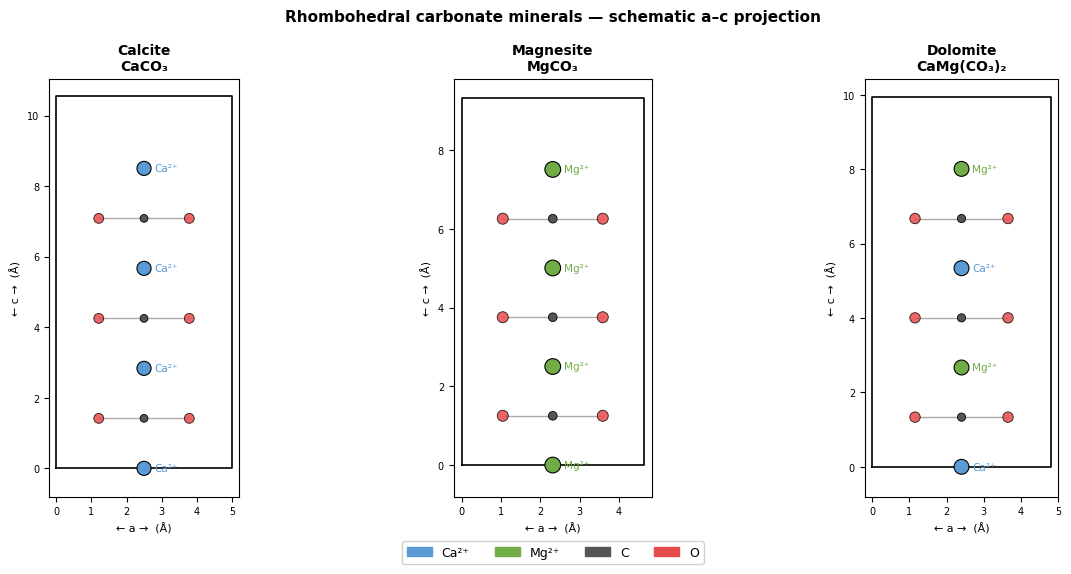

Ionic radii:  Ca²⁺ = 1.00 Å   Mg²⁺ = 0.72 Å
=> Mg–O bonds are shorter and stiffer than Ca–O


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(13, 5.5))

def draw_structure(ax, title, formula, cation_layers, colors, a, c, x_O):
    """Schematic a-c cross-section of a rhombohedral carbonate."""
    ax.set_xlim(-0.2, a + 0.2)
    ax.set_ylim(-0.8, c * 0.62 + 0.5)
    ax.set_aspect('equal')

    # Cell outline
    ax.plot([0, a, a, 0, 0], [0, 0, c*0.62, c*0.62, 0],
            'k-', lw=1.2, zorder=0)

    rM, rC, rO = 0.20, 0.11, 0.14

    # Cation layers (fractional z positions within the shown range)
    z_M_all = [0.0, 1/6, 1/3, 1/2]
    for i, zf in enumerate(z_M_all):
        zA = zf * c
        if zA > c * 0.62: break
        col = colors[i % len(colors)]
        label = cation_layers[i % len(cation_layers)]
        circ = plt.Circle((a/2, zA), rM, color=col, ec='k', lw=0.8, zorder=3)
        ax.add_patch(circ)
        ax.text(a/2 + rM + 0.08, zA, label, va='center', fontsize=7.5, color=col)

    # CO3 layers (z ~ 1/12, 3/12, 5/12, ...)
    z_C_all = [1/12, 3/12, 5/12]
    for zf in z_C_all:
        zA = zf * c
        if zA > c * 0.62: break
        # C
        ax.add_patch(plt.Circle((a/2, zA), rC, color='#555', ec='k', lw=0.6, zorder=4))
        # two O atoms in projection
        for dx in [-x_O * a, x_O * a]:
            xO = a/2 + dx
            ax.plot([a/2, np.clip(xO, 0, a)], [zA, zA], '-', color='#aaa', lw=1, zorder=2)
            ax.add_patch(plt.Circle((np.clip(xO, 0, a), zA), rO,
                                    color='#e84b4b', ec='k', lw=0.6, zorder=4, alpha=0.85))

    ax.set_title(f'{title}\n{formula}', fontsize=10, fontweight='bold')
    ax.set_xlabel('← a →  (Å)', fontsize=8)
    ax.set_ylabel('← c →  (Å)', fontsize=8)
    ax.tick_params(labelsize=7)

# Calcite: all Ca layers
draw_structure(axes[0], 'Calcite', 'CaCO₃',
               cation_layers=['Ca²⁺'], colors=['#5b9bd5'],
               a=4.990, c=17.002, x_O=0.257)

# Magnesite: all Mg layers
draw_structure(axes[1], 'Magnesite', 'MgCO₃',
               cation_layers=['Mg²⁺'], colors=['#70ad47'],
               a=4.634, c=15.015, x_O=0.274)

# Dolomite: alternating Ca / Mg layers
draw_structure(axes[2], 'Dolomite', 'CaMg(CO₃)₂',
               cation_layers=['Ca²⁺', 'Mg²⁺'], colors=['#5b9bd5', '#70ad47'],
               a=4.807, c=16.02, x_O=0.260)

# Shared legend
legend_handles = [
    mpatches.Patch(color='#5b9bd5', label='Ca²⁺'),
    mpatches.Patch(color='#70ad47', label='Mg²⁺'),
    mpatches.Patch(color='#555555', label='C'),
    mpatches.Patch(color='#e84b4b', label='O'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Rhombohedral carbonate minerals — schematic a–c projection',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('carbonate_structures.png', dpi=150, bbox_inches='tight')
plt.show()
print("Ionic radii:  Ca²⁺ = 1.00 Å   Mg²⁺ = 0.72 Å")
print("=> Mg–O bonds are shorter and stiffer than Ca–O")

---
## 2 · Force Field

GULP uses an **empirical force field** (interatomic potential) to compute the
energy of the crystal as a function of atomic positions and cell parameters.

### Shell model (Dick & Overhauser 1958)
Each oxygen is split into a **core** (nucleus + inner electrons, mass = full O mass)
and a **shell** (outer electron cloud, massless), connected by a harmonic spring:

$$E_{\text{spring}} = k_2\,|\mathbf{r}_{\text{core}} - \mathbf{r}_{\text{shell}}|^2$$

The shell can displace relative to the core, mimicking **ionic polarisability**
and reproducing experimental dielectric constants.

### Interaction potentials

| Interaction | Potential | Formula |
|-------------|-----------|---------|
| M²⁺ – O (long-range) | Buckingham | $A\,e^{-r/\rho} - C/r^6$ |
| O – O (between CO₃ groups) | Buckingham (inter) | same form |
| O – O (within CO₃) | Buckingham (intra) | same form, short cutoff |
| C – O (covalent bond) | Morse | $D_e[1-e^{-a(r-r_0)}]^2$ |
| O – C – O (120° angle) | Three-body harmonic | $k(\theta - 120°)^2$ |
| CO₃ planarity | Out-of-plane | $k_2\,h^2$ |

**Parameters (Rohl, Wright & Gale 2003; Fisler, Gale & Cygan 2000):**

| Pair | A (eV) | ρ (Å) | C (eV·Å⁶) |
|------|--------|--------|-----------|
| Ca–O | 2154.0 | 0.2891 | 0 |
| Mg–O | 1039.6 | 0.2893 | 0 |
| O–O (inter) | 64242.5 | 0.1989 | 21.84 |
| O–O (intra) | 4030.3 | 0.2455 | 0 |

| C–O Morse | $D_e$ = 5.0 eV | $a$ = 2.5228 Å⁻¹ | $r_0$ = 1.1982 Å |
| Three-body | $k$ = 1.7995 eV/rad² | $\theta_0$ = 120° | — |
| O spring | $k_2$ = 52.74 eV/Å² | — | — |

Note that **Ca–O and Mg–O** Buckingham parameters differ significantly:
Mg²⁺ is smaller and harder, producing a shorter, stiffer bond.

---
## 3 · Running GULP on the Cluster (`granado.uninorte.edu.co`)

### Step 1 — Connect to the cluster

```bash
ssh your_username@granado.uninorte.edu.co
```

Once logged in, create a working directory for this tutorial:

```bash
mkdir -p ~/gulp_tutorial
cd ~/gulp_tutorial
```

### Step 2 — Upload your input files

From your **laptop**, copy the `.gin` files to the cluster:

```bash
scp calcite.gin magnesite.gin dolomite.gin \
    your_username@granado.uninorte.edu.co:~/gulp_tutorial/
```

### Step 3 — Create a SLURM submission script

Create a file called `run_gulp.sh` in `~/gulp_tutorial/` with the following content.
**Change `calcite.gin` / `calcite.gout` for each mineral you want to run.**

```bash
#!/bin/bash

#SBATCH -J gulp_calcite          # Job name (change per mineral)
#SBATCH -o out                   # Standard output file
#SBATCH -e err                   # Standard error file
#SBATCH -N 1                     # Number of nodes
#SBATCH -n 1                     # Number of CPU cores
#SBATCH -t 00:10:00              # Wall time (hh:mm:ss) — 10 min is plenty
#SBATCH -p phys_general          # Partition
#SBATCH --mem 32000M             # Memory

module load gnu11/11.2

mpirun -n 1 /home/physics/geochem/gulp-6.1.2/Src/gulp < calcite.gin > calcite.gout
```

Submit with:
```bash
sbatch run_gulp.sh
```

### Step 4 — Monitor and repeat for each mineral

```bash
squeue -u your_username          # check job status (R=running, PD=pending)
tail -f calcite.gout             # watch output as it is written
```

Edit `run_gulp.sh` to change the input/output filenames, then resubmit for
magnesite and dolomite:

```bash
# For magnesite:
sed -i 's/calcite/magnesite/g' run_gulp.sh
sbatch run_gulp.sh

# For dolomite:
sed -i 's/magnesite/dolomite/g' run_gulp.sh
sbatch run_gulp.sh
```

### Step 5 — Download results to your laptop

```bash
scp your_username@granado.uninorte.edu.co:~/gulp_tutorial/*.gout .
```

### Complete workflow at a glance

```
Your laptop                        granado cluster
───────────────                    ──────────────────────────────────
1. Save .gin files ──── scp ─────► ~/gulp_tutorial/
2.                                 Edit run_gulp.sh (input/output names)
3.                                 sbatch run_gulp.sh   (repeat x3)
4.                                 GULP writes .gout files
5. Open this notebook ◄── scp ───  download *.gout
6. Run analysis cells below
```

> **GULP binary location on granado:**
> `/home/physics/geochem/gulp-6.1.2/Src/gulp`
>
> **Module to load:**
> `module load gnu11/11.2`

---
## Exercise 1 · Energy Minimisation

**Goal:** Optimise the crystal structures of calcite, magnesite, and dolomite
and compare their lattice energies, cell parameters, and bulk moduli.

**GULP keywords used:**

| Keyword | Meaning |
|---------|---------|
| `opti` | Perform geometry optimisation |
| `conp` | Constant pressure — relax both atomic positions and cell shape |
| `comp` | Print comparison of initial vs final structure |
| `mole` | Identify molecular units (CO₃ groups) for intra/inter potential separation |
| `phonon` | Calculate vibrational frequencies at the end |
| `elas` | Compute the full elastic constant tensor C_ij and derived moduli |
| `temperature 0 1000 100` | Compute Helmholtz free energy A(T) at 0, 100, …, 1000 K |

**Key results to find in the output file:**
- `Total lattice energy` — in eV/cell
- `Final cell parameters` — optimised *a*, *c* values
- `Bulk Modulus (VRH)` — in GPa
- `Elastic Constant Matrix` — full 6×6 C_ij tensor (GPa)
- `Velocity S-wave / P-wave` — seismic wave speeds (km/s)
- `Phonon frequencies` — in cm⁻¹ (if `phonon` keyword is active)
- `Helmholtz free energy` — A(T) at geological temperatures

---

### Input file 1: Calcite (CaCO₃)

Save the text below as **`calcite.gin`** and upload to the cluster.

In [2]:
# Display the calcite input file
calcite_gin = '''opti conp mole phonon comp elas

# Created by GDIS version 0.90.0
#

name calcite-P1

pressure 0.0 GPa

cell
4.990000 4.990000 17.002000  90.000000 90.000000 120.000000
fractional
Ca   core     0.000000    0.000000    0.000000    1.0000000
C1   core     0.000000    0.000000    0.250000    1.0000000
O1   core     0.257060    0.000000    0.250000    1.0000000
O1   core     0.000000    0.257060    0.250000    1.0000000
O1   core    -0.257060   -0.257060    0.250000    1.0000000
Ca   core     0.000000    0.000000    0.500000    1.0000000
C1   core     0.000000    0.000000    0.750000    1.0000000
O1   core    -0.257060    0.000000    0.750000    1.0000000
O1   core     0.000000   -0.257060    0.750000    1.0000000
O1   core     0.257060    0.257060    0.750000    1.0000000
Ca   core     0.666667    0.333333    0.333333    1.0000000
C1   core     0.666667    0.333333    0.583333    1.0000000
O1   core     0.923727    0.333333    0.583333    1.0000000
O1   core     0.666667    0.590393    0.583333    1.0000000
O1   core     0.409607    0.076273    0.583333    1.0000000
Ca   core     0.666667    0.333333    0.833333    1.0000000
C1   core     0.666667    0.333333    0.083333    1.0000000
O1   core     0.409607    0.333333    0.083333    1.0000000
O1   core     0.666667    0.076273    0.083333    1.0000000
O1   core     0.923727    0.590393    0.083333    1.0000000
Ca   core     0.333333    0.666667    0.666667    1.0000000
C1   core     0.333333    0.666667    0.916667    1.0000000
O1   core     0.590393    0.666667    0.916667    1.0000000
O1   core     0.333333    0.923727    0.916667    1.0000000
O1   core     0.076273    0.409607    0.916667    1.0000000
Ca   core     0.333333    0.666667    0.166667    1.0000000
C1   core     0.333333    0.666667    0.416667    1.0000000
O1   core     0.076273    0.666667    0.416667    1.0000000
O1   core     0.333333    0.409607    0.416667    1.0000000
O1   core     0.590393    0.923727    0.416667    1.0000000
O1   shel     0.590393    0.923727    0.416667    1.0000000
O1   shel     0.333333    0.409607    0.416667    1.0000000
O1   shel     0.076273    0.666667    0.416667    1.0000000
O1   shel     0.076273    0.409607    0.916667    1.0000000
O1   shel     0.333333    0.923727    0.916667    1.0000000
O1   shel     0.590393    0.666667    0.916667    1.0000000
O1   shel     0.923727    0.590393    0.083333    1.0000000
O1   shel     0.666667    0.076273    0.083333    1.0000000
O1   shel     0.409607    0.333333    0.083333    1.0000000
O1   shel     0.409607    0.076273    0.583333    1.0000000
O1   shel     0.666667    0.590393    0.583333    1.0000000
O1   shel     0.923727    0.333333    0.583333    1.0000000
O1   shel     0.257060    0.257060    0.750000    1.0000000
O1   shel     0.000000   -0.257060    0.750000    1.0000000
O1   shel    -0.257060    0.000000    0.750000    1.0000000
O1   shel    -0.257060   -0.257060    0.250000    1.0000000
O1   shel     0.000000    0.257060    0.250000    1.0000000
O1   shel     0.257060    0.000000    0.250000    1.0000000

space
P 1

species 4
Ca core 2.000000
C  core 1.343539
O  core 1.018487
O  shel -2.133
end

shrink 4

buck
Ca  core  C   core    1.2E8     0.120     0.0000   0.00      10.0
buck
Ca  core  O   shel   2154.000   0.289118     0.0000   0.00    10.0
buck
Mg  core  O   shel   1039.59    0.2893        0.0000  0.00    10.0
buck intra
O     core O     core    4030.300     0.245497   0.0000       0.00   2.50
buck inter
O     shel O     shel  64242.4540     0.198913  21.8436       0.00  15.0
morse intra bond
C core O core  5.000   2.5228   1.19820  0.00
spring
O  52.7400
three  bond intra regular
C core O core O core  1.7995  120.00
outofplane bond intra
C cor  O  cor  O cor O cor     8.6892     360.0

temperature 0 1000 100

output xyz relaxed-calcite.xyz
output freq text band-26.dat
dump relaxed-calcite.res
print 1
'''
print(calcite_gin)

opti conp mole phonon comp elas

# Created by GDIS version 0.90.0
#

name calcite-P1

pressure 0.0 GPa

cell
4.990000 4.990000 17.002000  90.000000 90.000000 120.000000
fractional
Ca   core     0.000000    0.000000    0.000000    1.0000000
C1   core     0.000000    0.000000    0.250000    1.0000000
O1   core     0.257060    0.000000    0.250000    1.0000000
O1   core     0.000000    0.257060    0.250000    1.0000000
O1   core    -0.257060   -0.257060    0.250000    1.0000000
Ca   core     0.000000    0.000000    0.500000    1.0000000
C1   core     0.000000    0.000000    0.750000    1.0000000
O1   core    -0.257060    0.000000    0.750000    1.0000000
O1   core     0.000000   -0.257060    0.750000    1.0000000
O1   core     0.257060    0.257060    0.750000    1.0000000
Ca   core     0.666667    0.333333    0.333333    1.0000000
C1   core     0.666667    0.333333    0.583333    1.0000000
O1   core     0.923727    0.333333    0.583333    1.0000000
O1   core     0.666667    0.590393    0.

In [3]:
# Save to disk so you can upload it to the cluster
with open("calcite.gin", "w") as f:
    f.write(calcite_gin)
print("Saved: calcite.gin")
print("Output files this run will produce:")
print("  relaxed-calcite.xyz   (optimised atomic positions)")
print("  relaxed-calcite.res   (GULP restart file)")
print("  band-26.dat           (phonon frequencies)")

Saved: calcite.gin
Output files this run will produce:
  relaxed-calcite.xyz   (optimised atomic positions)
  relaxed-calcite.res   (GULP restart file)
  band-26.dat           (phonon frequencies)


---
### Input file 2: Magnesite (MgCO₃)

The structure is identical to calcite (same R$\overline{3}$c topology, expanded to P1)
but Ca²⁺ is replaced by Mg²⁺ throughout.
Note the different Mg–O Buckingham parameters: **A = 1039.6 eV, ρ = 0.2893 Å**
(vs Ca–O: A = 2154.0, ρ = 0.2891).
The smaller A and nearly identical ρ reflect the smaller, harder Mg²⁺ cation.

Save as **`magnesite.gin`**.

In [4]:
magnesite_gin = '''opti conp mole phonon comp elas

# Created by GDIS version 0.90.0
#

name magnesite-P1

pressure 0.0 GPa

cell
4.990000 4.990000 17.002000  90.000000 90.000000 120.000000
fractional
Mg   core     0.000000    0.000000    0.000000    1.0000000
C1   core     0.000000    0.000000    0.250000    1.0000000
O1   core     0.257060    0.000000    0.250000    1.0000000
O1   core     0.000000    0.257060    0.250000    1.0000000
O1   core    -0.257060   -0.257060    0.250000    1.0000000
Mg   core     0.000000    0.000000    0.500000    1.0000000
C1   core     0.000000    0.000000    0.750000    1.0000000
O1   core    -0.257060    0.000000    0.750000    1.0000000
O1   core     0.000000   -0.257060    0.750000    1.0000000
O1   core     0.257060    0.257060    0.750000    1.0000000
Mg   core     0.666667    0.333333    0.333333    1.0000000
C1   core     0.666667    0.333333    0.583333    1.0000000
O1   core     0.923727    0.333333    0.583333    1.0000000
O1   core     0.666667    0.590393    0.583333    1.0000000
O1   core     0.409607    0.076273    0.583333    1.0000000
Mg   core     0.666667    0.333333    0.833333    1.0000000
C1   core     0.666667    0.333333    0.083333    1.0000000
O1   core     0.409607    0.333333    0.083333    1.0000000
O1   core     0.666667    0.076273    0.083333    1.0000000
O1   core     0.923727    0.590393    0.083333    1.0000000
Mg   core     0.333333    0.666667    0.666667    1.0000000
C1   core     0.333333    0.666667    0.916667    1.0000000
O1   core     0.590393    0.666667    0.916667    1.0000000
O1   core     0.333333    0.923727    0.916667    1.0000000
O1   core     0.076273    0.409607    0.916667    1.0000000
Mg   core     0.333333    0.666667    0.166667    1.0000000
C1   core     0.333333    0.666667    0.416667    1.0000000
O1   core     0.076273    0.666667    0.416667    1.0000000
O1   core     0.333333    0.409607    0.416667    1.0000000
O1   core     0.590393    0.923727    0.416667    1.0000000
O1   shel     0.590393    0.923727    0.416667    1.0000000
O1   shel     0.333333    0.409607    0.416667    1.0000000
O1   shel     0.076273    0.666667    0.416667    1.0000000
O1   shel     0.076273    0.409607    0.916667    1.0000000
O1   shel     0.333333    0.923727    0.916667    1.0000000
O1   shel     0.590393    0.666667    0.916667    1.0000000
O1   shel     0.923727    0.590393    0.083333    1.0000000
O1   shel     0.666667    0.076273    0.083333    1.0000000
O1   shel     0.409607    0.333333    0.083333    1.0000000
O1   shel     0.409607    0.076273    0.583333    1.0000000
O1   shel     0.666667    0.590393    0.583333    1.0000000
O1   shel     0.923727    0.333333    0.583333    1.0000000
O1   shel     0.257060    0.257060    0.750000    1.0000000
O1   shel     0.000000   -0.257060    0.750000    1.0000000
O1   shel    -0.257060    0.000000    0.750000    1.0000000
O1   shel    -0.257060   -0.257060    0.250000    1.0000000
O1   shel     0.000000    0.257060    0.250000    1.0000000
O1   shel     0.257060    0.000000    0.250000    1.0000000

space
P 1

species 4
Mg core 2.00000
C  core 1.343539
O  core 1.018487
O  shel -2.133
end

shrink 4

buck
Mg  core  O   shel   1039.59    0.2893        0.0000  0.00    10.0
buck
Mg  core  C   core  26164795.4  0.120000  0.000000    0.00 10.00
buck intra
O     core O     core    4030.300     0.245497   0.0000       0.00   2.50
buck inter
O     shel O     shel  64242.4540     0.198913  21.8436       0.00  15.0
morse intra bond
C core O core  5.000   2.5228   1.19820  0.00

spring
O  52.7400

three  bond intra regular
C core O core O core  1.7995  120.00

outofplane bond intra
C cor  O  cor  O cor O cor     8.6892     360.0

temperature 0 1000 100

output xyz relaxed-magnesite.xyz
output freq text band-24.dat
dump relaxed-magnesite.res
print 1
'''
print(magnesite_gin)

opti conp mole phonon comp elas

# Created by GDIS version 0.90.0
#

name magnesite-P1

pressure 0.0 GPa

cell
4.990000 4.990000 17.002000  90.000000 90.000000 120.000000
fractional
Mg   core     0.000000    0.000000    0.000000    1.0000000
C1   core     0.000000    0.000000    0.250000    1.0000000
O1   core     0.257060    0.000000    0.250000    1.0000000
O1   core     0.000000    0.257060    0.250000    1.0000000
O1   core    -0.257060   -0.257060    0.250000    1.0000000
Mg   core     0.000000    0.000000    0.500000    1.0000000
C1   core     0.000000    0.000000    0.750000    1.0000000
O1   core    -0.257060    0.000000    0.750000    1.0000000
O1   core     0.000000   -0.257060    0.750000    1.0000000
O1   core     0.257060    0.257060    0.750000    1.0000000
Mg   core     0.666667    0.333333    0.333333    1.0000000
C1   core     0.666667    0.333333    0.583333    1.0000000
O1   core     0.923727    0.333333    0.583333    1.0000000
O1   core     0.666667    0.590393    

In [5]:
with open("magnesite.gin", "w") as f:
    f.write(magnesite_gin)
print("Saved: magnesite.gin")
print("Output files this run will produce:")
print("  relaxed-magnesite.xyz   (optimised atomic positions)")
print("  relaxed-magnesite.res   (GULP restart file)")
print("  band-24.dat             (phonon frequencies)")

Saved: magnesite.gin
Output files this run will produce:
  relaxed-magnesite.xyz   (optimised atomic positions)
  relaxed-magnesite.res   (GULP restart file)
  band-24.dat             (phonon frequencies)


---
### Input file 3: Dolomite (CaMg(CO₃)₂)

Dolomite has **ordered alternating Ca and Mg layers** along the *c*-axis.
The structure has lower symmetry than calcite/magnesite (R$\overline{3}$ vs R$\overline{3}$c)
because the Ca and Mg layers break the glide-plane symmetry.

The input below uses a **triclinic P1 expansion** of the rhombohedral cell —
all 80 atoms are listed explicitly. This is the format generated by GDIS
(the visualisation program used to prepare your inputs).

Both Ca–O and Mg–O Buckingham parameters are active simultaneously.

Save as **`dolomite.gin`**.

In [6]:
dolomite_gin = '''#
# Keywords:
#
opti conp comp phonon mole elas
#
# Options:
#
cell
  11.977695  12.009314   6.004657  46.977393  47.347616  47.346984

fractional  1
Ca    core 0.5000000 0.0000000 0.0000000 2.00000000 1.00000 0.00000
Ca    core 0.5000367 0.5000158 0.9999521 2.00000000 1.00000 0.00000
Ca    core 0.7693350 0.2402966 0.4806526 2.00000000 1.00000 0.00000
Ca    core 0.7693513 0.7403219 0.4805755 2.00000000 1.00000 0.00000
C     core 0.6346920 0.1181236 0.2443659 1.34353899 1.00000 0.00000
C     core 0.6347006 0.6181089 0.2443381 1.34353899 1.00000 0.00000
C     core 0.1346823 0.1101642 0.2602895 1.34353899 1.00000 0.00000
C     core 0.1346939 0.6101705 0.2602707 1.34353899 1.00000 0.00000
C     core 0.8964609 0.8561055 0.7398020 1.34353899 1.00000 0.00000
C     core 0.8964524 0.3561082 0.7398195 1.34353899 1.00000 0.00000
C     core 0.3729291 0.8703885 0.7684337 1.34353899 1.00000 0.00000
C     core 0.3729247 0.3703890 0.7684036 1.34353899 1.00000 0.00000
O     core 0.7712322 0.9955451 0.2561584 1.01848700 1.00000 0.00000
O     core 0.7712411 0.4955289 0.2561207 1.01848700 1.00000 0.00000
O     core 0.2565972 0.9731659 0.2600974 1.01848700 1.00000 0.00000
O     core 0.2566251 0.4731850 0.2600445 1.01848700 1.00000 0.00000
O     core 0.1346995 0.7421481 0.9963012 1.01848700 1.00000 0.00000
O     core 0.1347188 0.2421347 0.9963063 1.01848700 1.00000 0.00000
O     core 0.6346920 0.7490481 0.9825041 1.01848700 1.00000 0.00000
O     core 0.6346875 0.2490581 0.9825209 1.01848700 1.00000 0.00000
O     core 0.0127467 0.1102989 0.5342484 1.01848700 1.00000 0.00000
O     core 0.0127617 0.6102796 0.5342405 1.01848700 1.00000 0.00000
O     core 0.4981580 0.1122044 0.4895197 1.01848700 1.00000 0.00000
O     core 0.4981686 0.6121948 0.4895096 1.01848700 1.00000 0.00000
O     core 0.2508047 0.0080219 0.7335076 1.01848700 1.00000 0.00000
O     core 0.2508050 0.5080278 0.7334673 1.01848700 1.00000 0.00000
O     core 0.7616214 0.9787378 0.7867109 1.01848700 1.00000 0.00000
O     core 0.7616267 0.4787620 0.7866237 1.01848700 1.00000 0.00000
O     core 0.9104504 0.2163402 0.9834448 1.01848700 1.00000 0.00000
O     core 0.9105062 0.7163097 0.9833930 1.01848700 1.00000 0.00000
O     core 0.3589028 0.2485961 0.0479787 1.01848700 1.00000 0.00000
O     core 0.3589186 0.7485851 0.0479913 1.01848700 1.00000 0.00000
O     core 0.0185696 0.8735877 0.4645150 1.01848700 1.00000 0.00000
O     core 0.0185897 0.3735443 0.4645945 1.01848700 1.00000 0.00000
O     core 0.5077615 0.8469418 0.5231427 1.01848700 1.00000 0.00000
O     core 0.5077605 0.3469333 0.5231266 1.01848700 1.00000 0.00000
Mg    core 0.0186179 0.9868988 0.9932551 2.00000000 1.00000 0.00000
Mg    core 0.0186193 0.4868833 0.9932477 2.00000000 1.00000 0.00000
Mg    core 0.2507605 0.2436747 0.5068376 2.00000000 1.00000 0.00000
Mg    core 0.2507590 0.7436454 0.5068879 2.00000000 1.00000 0.00000
O     shel 0.7735190 0.9942156 0.2527276 -2.1330000 1.00000 0.00000
O     shel 0.7735278 0.4942005 0.2526956 -2.1330000 1.00000 0.00000
O     shel 0.2561676 0.9714804 0.2651137 -2.1330000 1.00000 0.00000
O     shel 0.2561911 0.4714996 0.2650610 -2.1330000 1.00000 0.00000
O     shel 0.1347016 0.7434886 0.9936110 -2.1330000 1.00000 0.00000
O     shel 0.1347210 0.2434779 0.9936183 -2.1330000 1.00000 0.00000
O     shel 0.6346909 0.7490111 0.9825802 -2.1330000 1.00000 0.00000
O     shel 0.6346882 0.2490189 0.9825948 -2.1330000 1.00000 0.00000
O     shel 0.0131817 0.1077871 0.5376253 -2.1330000 1.00000 0.00000
O     shel 0.0131963 0.6077680 0.5376157 -2.1330000 1.00000 0.00000
O     shel 0.4958703 0.1139175 0.4921823 -2.1330000 1.00000 0.00000
O     shel 0.4958806 0.6139099 0.4921725 -2.1330000 1.00000 0.00000
O     shel 0.2493958 0.0083482 0.7341224 -2.1330000 1.00000 0.00000
O     shel 0.2493974 0.5083562 0.7340853 -2.1330000 1.00000 0.00000
O     shel 0.7609950 0.9790828 0.7881313 -2.1330000 1.00000 0.00000
O     shel 0.7609958 0.4791079 0.7880487 -2.1330000 1.00000 0.00000
O     shel 0.9102395 0.2157850 0.9863615 -2.1330000 1.00000 0.00000
O     shel 0.9102932 0.7157543 0.9863119 -2.1330000 1.00000 0.00000
O     shel 0.3591153 0.2471366 0.0490872 -2.1330000 1.00000 0.00000
O     shel 0.3591338 0.7471229 0.0490940 -2.1330000 1.00000 0.00000
O     shel 0.0199752 0.8732777 0.4638670 -2.1330000 1.00000 0.00000
O     shel 0.0199997 0.3732327 0.4639459 -2.1330000 1.00000 0.00000
O     shel 0.5083894 0.8462295 0.5224516 -2.1330000 1.00000 0.00000
O     shel 0.5083891 0.3462231 0.5224389 -2.1330000 1.00000 0.00000

shrink   4


species   5
Ca     core    2.000000
Mg     core    2.000000
C      core    1.343539
O      core    1.018487
O      shel   -2.133000
end


element
cova Mg 0.0
end

Pressure 0.0 GPa


buck
C     core Ca    core  1.2E8     0.120000  0.000000      0.00 10.00
buck
Ca    core O     shel  2154.00000     0.289118  0.000000      0.00 10.00
buck
Mg    core O     shel  1039.59000     0.289300  0.000000      0.00 10.00
buck intra
O     core O     core  4030.30000     0.245497  0.000000      0.00  2.50
buck inter
O     shel O     shel  64242.4540     0.198913  21.84360      0.00 15.00
morse intra bond
C     core O     core 5.0000000     2.5228      1.19820  0.0000
spring
O      52.740000
three bond intra regular
C     core O     core O     core 1.7995     120.00
outofplane bond intra
C     cor O     cor O     cor O     cor   8.6892       360.00

temperature 0 1000 100

dump relaxed-dolomite.res
output freq text band-40.dat
output xyz relaxed-dolomite.xyz
'''
print(dolomite_gin[:2000], "\n... [truncated for display] ...")

#
# Keywords:
#
opti conp comp phonon mole elas
#
# Options:
#
cell
  11.977695  12.009314   6.004657  46.977393  47.347616  47.346984

fractional  1
Ca    core 0.5000000 0.0000000 0.0000000 2.00000000 1.00000 0.00000
Ca    core 0.5000367 0.5000158 0.9999521 2.00000000 1.00000 0.00000
Ca    core 0.7693350 0.2402966 0.4806526 2.00000000 1.00000 0.00000
Ca    core 0.7693513 0.7403219 0.4805755 2.00000000 1.00000 0.00000
C     core 0.6346920 0.1181236 0.2443659 1.34353899 1.00000 0.00000
C     core 0.6347006 0.6181089 0.2443381 1.34353899 1.00000 0.00000
C     core 0.1346823 0.1101642 0.2602895 1.34353899 1.00000 0.00000
C     core 0.1346939 0.6101705 0.2602707 1.34353899 1.00000 0.00000
C     core 0.8964609 0.8561055 0.7398020 1.34353899 1.00000 0.00000
C     core 0.8964524 0.3561082 0.7398195 1.34353899 1.00000 0.00000
C     core 0.3729291 0.8703885 0.7684337 1.34353899 1.00000 0.00000
C     core 0.3729247 0.3703890 0.7684036 1.34353899 1.00000 0.00000
O     core 0.7712322 0.9955451 0.2

In [7]:
with open("dolomite.gin", "w") as f:
    f.write(dolomite_gin)
print("Saved: dolomite.gin")
print("Output files this run will produce:")
print("  relaxed-dolomite.xyz   (optimised atomic positions)")
print("  relaxed-dolomite.res   (GULP restart file)")
print("  band-40.dat            (phonon frequencies)")

# ── Also save the SLURM submission scripts ────────────────────────────────
SLURM_TEMPLATE = """#!/bin/bash
#SBATCH -J gulp_{mineral}
#SBATCH -o out_{mineral}
#SBATCH -e err_{mineral}
#SBATCH -N 1
#SBATCH -n 1
#SBATCH -t 00:10:00
#SBATCH -p phys_general
#SBATCH --mem 32000M

module load gnu11/11.2
mpirun -n 1 /home/physics/geochem/gulp-6.1.2/Src/gulp < {mineral}.gin > {mineral}.gout
"""

for mineral in ["calcite", "magnesite", "dolomite"]:
    fname = f"run_{mineral}.sh"
    with open(fname, "w") as f:
        f.write(SLURM_TEMPLATE.format(mineral=mineral))
    print(f"Saved: {fname}")

print("\nFiles ready to upload to granado:")
print("  calcite.gin  magnesite.gin  dolomite.gin")
print("  run_calcite.sh  run_magnesite.sh  run_dolomite.sh")

Saved: dolomite.gin
Output files this run will produce:
  relaxed-dolomite.xyz   (optimised atomic positions)
  relaxed-dolomite.res   (GULP restart file)
  band-40.dat            (phonon frequencies)
Saved: run_calcite.sh
Saved: run_magnesite.sh
Saved: run_dolomite.sh

Files ready to upload to granado:
  calcite.gin  magnesite.gin  dolomite.gin
  run_calcite.sh  run_magnesite.sh  run_dolomite.sh


---
### Submitting Exercise 1 to the cluster

Upload the three `.gin` files saved above, then submit one job per mineral.
The SLURM script below is ready to copy — just paste it into a file on granado.

**`run_calcite.sh`**
```bash
#!/bin/bash
#SBATCH -J gulp_calcite
#SBATCH -o out_calcite
#SBATCH -e err_calcite
#SBATCH -N 1
#SBATCH -n 1
#SBATCH -t 00:10:00
#SBATCH -p phys_general
#SBATCH --mem 32000M

module load gnu11/11.2
mpirun -n 1 /home/physics/geochem/gulp-6.1.2/Src/gulp < calcite.gin > calcite.gout
```

**`run_magnesite.sh`** — identical, replace `calcite` with `magnesite`

**`run_dolomite.sh`** — identical, replace `calcite` with `dolomite`

Submit all three:
```bash
sbatch run_calcite.sh
sbatch run_magnesite.sh
sbatch run_dolomite.sh
squeue -u your_username   # monitor
```

**Expected run times on granado:**
| Mineral | Atoms in cell | Expected time |
|---------|--------------|---------------|
| Calcite | 60 | < 1 min |
| Magnesite | 60 | < 1 min |
| Dolomite | 80 | 1–3 min |

When all jobs show status `C` (completed) in `squeue`, download the results:
```bash
scp your_username@granado.uninorte.edu.co:~/gulp_tutorial/*.gout .
```

Then continue with the analysis cells below.

---
### Exercise 1 — Results Analysis

Once you have copied the `.gout` files back to your laptop, run the cells below.
They will parse the GULP output and produce a comparison table and plots.

In [8]:
import re, os
import numpy as np
import matplotlib.pyplot as plt

# ── Parsing helpers ────────────────────────────────────────────────────────
def read_gout(filename):
    if not os.path.exists(filename):
        print(f"File not found: {filename}  (run GULP first)")
        return ""
    return open(filename).read()

def parse_energy(text):
    """Total lattice energy in eV."""
    m = re.search(r"Total lattice energy\s*=\s*(-[\d.]+)\s*eV", text)
    return float(m.group(1)) if m else None

def parse_cell(text):
    """Return dict with a, b, c, alpha, beta, gamma from final cell block."""
    out = {}
    for key in ['a','b','c','alpha','beta','gamma']:
        m = re.search(rf"^\s+{key}\s+=\s+([\d.]+)", text, re.M)
        if m: out[key] = float(m.group(1))
    return out

def parse_bulk(text):
    """Bulk modulus Hill average in GPa. Format: Bulk  Modulus (GPa) = <Reuss> <Voigt> <Hill>"""
    m = re.search(r'Bulk\s+Modulus\s*\(GPa\)\s*=\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', text)
    if m: return float(m.group(3))   # group 3 = Hill
    return None

def check_converged(text, name):
    if "Optimisation achieved" in text:
        print(f"  ✓ {name}: converged")
    elif "ERROR" in text:
        errs = [l.strip() for l in text.split('\n') if 'ERROR' in l]
        print(f"  ✗ {name}: {errs[0] if errs else 'error in .gout'}")
    else:
        print(f"  ? {name}: check .gout for convergence")

# ── Load output files ──────────────────────────────────────────────────────
text_c = read_gout("calcite.gout")
text_m = read_gout("magnesite.gout")
text_d = read_gout("dolomite.gout")

for txt, name in [(text_c,"Calcite"),(text_m,"Magnesite"),(text_d,"Dolomite")]:
    if txt: check_converged(txt, name)

  ✓ Calcite: converged
  ✓ Magnesite: converged
  ✓ Dolomite: converged


In [11]:
# ── Results table ──────────────────────────────────────────────────────────
minerals = ['Calcite', 'Magnesite', 'Dolomite']
texts    = [text_c,    text_m,      text_d]
# Experimental reference values
expt_a   = [4.990,     4.634,       4.807]
expt_c   = [17.061,    15.015,      16.002]
expt_K   = [73,        107,         94]       # GPa

print(f"{'':12s}  {'Calcite':>12s}  {'Magnesite':>12s}  {'Dolomite':>12s}")
print("─" * 56)

results = {}
for mineral, txt in zip(minerals, texts):
    if not txt:
        results[mineral] = {}
        continue
    results[mineral] = {
        'cell':   parse_cell(txt),
        'energy': parse_energy(txt),
        'K':      parse_bulk(txt),
    }

def row(label, vals):
    print(f"{label:12s}  " + "  ".join(f"{v:>12}" for v in vals))

row("a_opt (Å)",   [f"{results[m]['cell'].get('a','?'):.4f}" for m in minerals])
row("a_expt (Å)",  [f"{v:.3f}" for v in expt_a])
row("c_opt (Å)",   [f"{results[m]['cell'].get('c','?'):.4f}" for m in minerals])
row("c_expt (Å)",  [f"{v:.3f}" for v in expt_c])
print("─" * 56)
row("E (eV/cell)", [f"{results[m]['energy'] or '?'}" for m in minerals])
row("K_opt (GPa)",  [f"{results[m]['K'] or '?'}" for m in minerals])
row("K_expt (GPa)", [str(v) for v in expt_K])

                   Calcite     Magnesite      Dolomite
────────────────────────────────────────────────────────
a_opt (Å)           4.9900        4.9900       11.9777
a_expt (Å)           4.990         4.634         4.807
c_opt (Å)          17.0020       17.0020        6.0047
c_expt (Å)          17.061        15.015        16.002
────────────────────────────────────────────────────────
E (eV/cell)   -255.40579428  -267.22387127  -352.12216206
K_opt (GPa)       80.97294     123.78667      92.07941
K_expt (GPa)            73           107            94


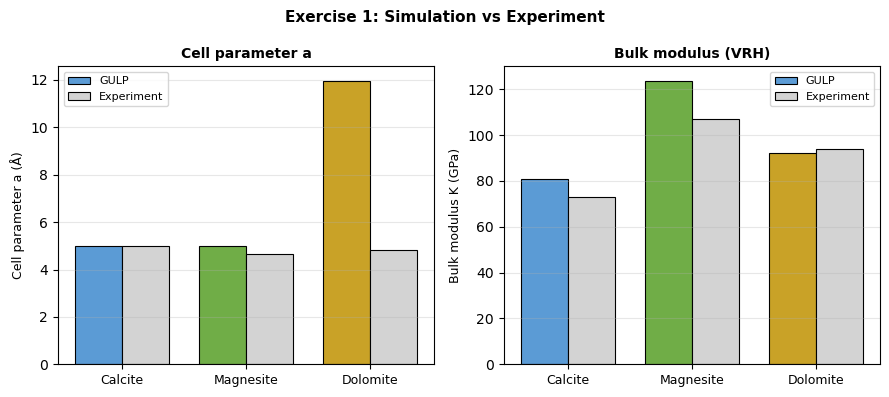


Geochemical interpretation:
  Ca²⁺ (r=1.00Å) > Mg²⁺ (r=0.72Å)  ⟹  a(calcite) > a(magnesite)
  Shorter Mg–O bonds  ⟹  higher bulk modulus for magnesite
  Dolomite sits between end-members (a, K both intermediate)


In [12]:
# ── Bar chart comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
colors = ['#5b9bd5', '#70ad47', '#c9a227']
x = np.arange(len(minerals))
width = 0.38

for ax, key, ylabel, expt_vals, title in [
    (axes[0], 'a', 'Cell parameter a (Å)', expt_a, 'Cell parameter a'),
    (axes[1], 'K', 'Bulk modulus K (GPa)', expt_K, 'Bulk modulus (VRH)'),
]:
    sim_vals = [results[m]['cell'].get(key) if key=='a'
                else results[m]['K'] for m in minerals]
    sim_vals = [v if v else 0 for v in sim_vals]

    bars = ax.bar(x - width/2, sim_vals, width, label='GULP', color=colors,
                  edgecolor='k', linewidth=0.8)
    ax.bar(x + width/2, expt_vals, width, label='Experiment',
           color='lightgrey', edgecolor='k', linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(minerals, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Exercise 1: Simulation vs Experiment', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('ex1_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGeochemical interpretation:")
print("  Ca²⁺ (r=1.00Å) > Mg²⁺ (r=0.72Å)  ⟹  a(calcite) > a(magnesite)")
print("  Shorter Mg–O bonds  ⟹  higher bulk modulus for magnesite")
print("  Dolomite sits between end-members (a, K both intermediate)")

---
## Exercise 2 · Lattice Dynamics — Phonons

**Goal:** Calculate the vibrational (phonon) frequencies of calcite and interpret
the modes in terms of internal CO₃ vibrations and lattice (Ca–O) modes.

Add the keyword **`phonon`** and a **`shrink`** directive to the calcite input.
The `shrink 4` line sets up a 4×4×4 Monkhorst-Pack Brillouin zone mesh.

Save as **`calcite_phonon.gin`** — it is identical to `calcite.gin` except
the first line adds `phonon` and we request frequency output.

**Expected run time on cluster:** 2–5 minutes.

In [13]:
calcite_phonon_gin = '''opti conp mole comp phonon

name calcite_phonon

pressure 0.0 GPa

cell
4.990000 4.990000 17.002000  90.000000 90.000000 120.000000

fractional
Ca   core     0.000000    0.000000    0.000000    1.0000000
C1   core     0.000000    0.000000    0.250000    1.0000000
O1   core     0.257060    0.000000    0.250000    1.0000000
O1   core     0.000000    0.257060    0.250000    1.0000000
O1   core    -0.257060   -0.257060    0.250000    1.0000000
Ca   core     0.000000    0.000000    0.500000    1.0000000
C1   core     0.000000    0.000000    0.750000    1.0000000
O1   core    -0.257060    0.000000    0.750000    1.0000000
O1   core     0.000000   -0.257060    0.750000    1.0000000
O1   core     0.257060    0.257060    0.750000    1.0000000
Ca   core     0.666667    0.333333    0.333333    1.0000000
C1   core     0.666667    0.333333    0.583333    1.0000000
O1   core     0.923727    0.333333    0.583333    1.0000000
O1   core     0.666667    0.590393    0.583333    1.0000000
O1   core     0.409607    0.076273    0.583333    1.0000000
Ca   core     0.666667    0.333333    0.833333    1.0000000
C1   core     0.666667    0.333333    0.083333    1.0000000
O1   core     0.409607    0.333333    0.083333    1.0000000
O1   core     0.666667    0.076273    0.083333    1.0000000
O1   core     0.923727    0.590393    0.083333    1.0000000
Ca   core     0.333333    0.666667    0.666667    1.0000000
C1   core     0.333333    0.666667    0.916667    1.0000000
O1   core     0.590393    0.666667    0.916667    1.0000000
O1   core     0.333333    0.923727    0.916667    1.0000000
O1   core     0.076273    0.409607    0.916667    1.0000000
Ca   core     0.333333    0.666667    0.166667    1.0000000
C1   core     0.333333    0.666667    0.416667    1.0000000
O1   core     0.076273    0.666667    0.416667    1.0000000
O1   core     0.333333    0.409607    0.416667    1.0000000
O1   core     0.590393    0.923727    0.416667    1.0000000
O1   shel     0.590393    0.923727    0.416667    1.0000000
O1   shel     0.333333    0.409607    0.416667    1.0000000
O1   shel     0.076273    0.666667    0.416667    1.0000000
O1   shel     0.076273    0.409607    0.916667    1.0000000
O1   shel     0.333333    0.923727    0.916667    1.0000000
O1   shel     0.590393    0.666667    0.916667    1.0000000
O1   shel     0.923727    0.590393    0.083333    1.0000000
O1   shel     0.666667    0.076273    0.083333    1.0000000
O1   shel     0.409607    0.333333    0.083333    1.0000000
O1   shel     0.409607    0.076273    0.583333    1.0000000
O1   shel     0.666667    0.590393    0.583333    1.0000000
O1   shel     0.923727    0.333333    0.583333    1.0000000
O1   shel     0.257060    0.257060    0.750000    1.0000000
O1   shel     0.000000   -0.257060    0.750000    1.0000000
O1   shel    -0.257060    0.000000    0.750000    1.0000000
O1   shel    -0.257060   -0.257060    0.250000    1.0000000
O1   shel     0.000000    0.257060    0.250000    1.0000000
O1   shel     0.257060    0.000000    0.250000    1.0000000

space
P 1

species
Ca  core   2.000000
C   core   1.343539
O   core   1.018487
O   shel  -2.133000

shrink 4

buck
Ca  core  C   core   1.2E8      0.120000  0.000000  0.00  10.0
buck
Ca  core  O   shel   2154.000   0.289118  0.000000  0.00  10.0
buck intra
O   core  O   core   4030.300   0.245497  0.000000  0.00   2.50
buck inter
O   shel  O   shel   64242.454  0.198913  21.84360  0.00  15.0
morse intra bond
C   core  O   core   5.000      2.5228    1.19820   0.00
spring
O   52.7400
three bond intra regular
C   core  O   core  O   core   1.7995   120.00
outofplane bond intra
C   core  O   core  O   core  O   core   8.6892   360.0

temperature  0.0  800.0  100.0

output xyz  calcite_phonon.xyz
output freq text calcite_freq.dat
dump        calcite_phonon.res
'''
print(calcite_phonon_gin[:1500], "\n...")
with open("calcite_phonon.gin", "w") as f:
    f.write(calcite_phonon_gin)
print("\nSaved: calcite_phonon.gin")

opti conp mole comp phonon

name calcite_phonon

pressure 0.0 GPa

cell
4.990000 4.990000 17.002000  90.000000 90.000000 120.000000

fractional
Ca   core     0.000000    0.000000    0.000000    1.0000000
C1   core     0.000000    0.000000    0.250000    1.0000000
O1   core     0.257060    0.000000    0.250000    1.0000000
O1   core     0.000000    0.257060    0.250000    1.0000000
O1   core    -0.257060   -0.257060    0.250000    1.0000000
Ca   core     0.000000    0.000000    0.500000    1.0000000
C1   core     0.000000    0.000000    0.750000    1.0000000
O1   core    -0.257060    0.000000    0.750000    1.0000000
O1   core     0.000000   -0.257060    0.750000    1.0000000
O1   core     0.257060    0.257060    0.750000    1.0000000
Ca   core     0.666667    0.333333    0.333333    1.0000000
C1   core     0.666667    0.333333    0.583333    1.0000000
O1   core     0.923727    0.333333    0.583333    1.0000000
O1   core     0.666667    0.590393    0.583333    1.0000000
O1   core     0.

### What to look for in `calcite_phonon.gout`

Search for the section **"Phonon Calculation"** or **"Frequencies"**.
The mode frequencies are given in **cm⁻¹** (wavenumbers).

Key modes in calcite:

| Mode | Assignment | Expected (cm⁻¹) |
|------|-----------|-----------------|
| Low frequency | Ca–O lattice modes | 50–300 |
| ν₂ | CO₃ out-of-plane bend | ~880 |
| ν₄ | CO₃ in-plane bend | ~710 |
| ν₁ | CO₃ symmetric stretch | ~1090 |
| ν₃ | CO₃ antisymmetric stretch | ~1400 |

**Important:** Check that **no imaginary frequencies** appear (shown as negative
numbers or marked with `i`). Imaginary frequencies indicate the structure is not
at a true energy minimum.

The `temperature 0.0 800.0 100.0` line causes GULP to also output the
**Helmholtz free energy** A(T) at 0, 100, 200, ... 800 K.

### Exercise 2 — Frequency and Free Energy Analysis

Found 94 frequencies
Range: 0.0 to 1514.7 cm⁻¹
Imaginary (negative): 0  ← OK


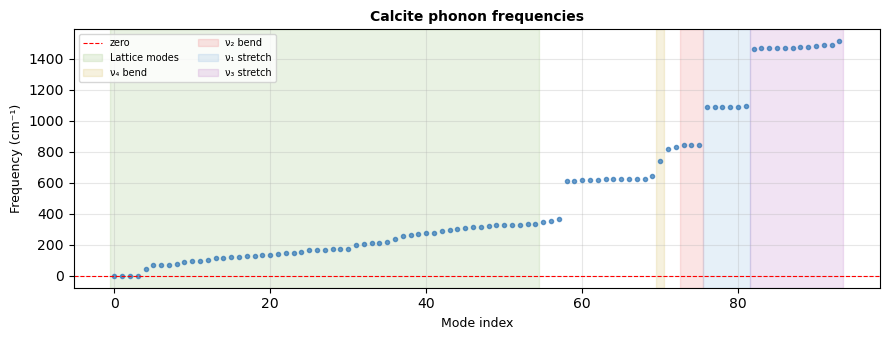

In [14]:
# ── Parse phonon frequencies from calcite_phonon.gout ─────────────────────
text_phon = read_gout("calcite_phonon.gout")

if text_phon:
    # Find frequency lines: GULP prints them as columns of numbers in cm^-1
    freq_section = re.search(
        r'Frequencies.*?\n(.*?)(?=\n\s*\n\s*[A-Z]|\Z)', text_phon, re.S)

    freqs = []
    if freq_section:
        for line in freq_section.group(1).split('\n'):
            nums = re.findall(r'-?[\d]+\.[\d]+', line)
            freqs.extend([float(n) for n in nums if abs(float(n)) < 5000])

    if freqs:
        freqs_arr = np.array(sorted(freqs))
        print(f"Found {len(freqs_arr)} frequencies")
        print(f"Range: {freqs_arr.min():.1f} to {freqs_arr.max():.1f} cm⁻¹")
        n_imag = (freqs_arr < 0).sum()
        print(f"Imaginary (negative): {n_imag}  {'← OK' if n_imag==0 else '← PROBLEM'}")

        fig, ax = plt.subplots(figsize=(9, 3.5))
        ax.plot(range(len(freqs_arr)), freqs_arr, 'o', ms=3, color='#2E75B6', alpha=0.7)
        ax.axhline(0, color='r', lw=0.8, ls='--', label='zero')
        # annotate key regions
        for label, ymin, ymax, color in [
            ('Lattice modes', 0, 350, '#70ad47'),
            ('ν₄ bend',     650, 750, '#c9a227'),
            ('ν₂ bend',     840, 920, '#e84b4b'),
            ('ν₁ stretch', 1060,1120, '#5b9bd5'),
            ('ν₃ stretch', 1380,1550, '#a649b0'),
        ]:
            mask = (freqs_arr>=ymin) & (freqs_arr<=ymax)
            if mask.any():
                idx = np.where(mask)[0]
                ax.axvspan(idx[0]-0.5, idx[-1]+0.5, alpha=0.15, color=color, label=label)

        ax.set_xlabel('Mode index', fontsize=9)
        ax.set_ylabel('Frequency (cm⁻¹)', fontsize=9)
        ax.set_title('Calcite phonon frequencies', fontsize=10, fontweight='bold')
        ax.legend(fontsize=7, loc='upper left', ncol=2)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('ex2_phonons.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("Could not parse frequencies automatically.")
        print("Search for 'Frequencies' in calcite_phonon.gout")
else:
    print("calcite_phonon.gout not found — run GULP first.")

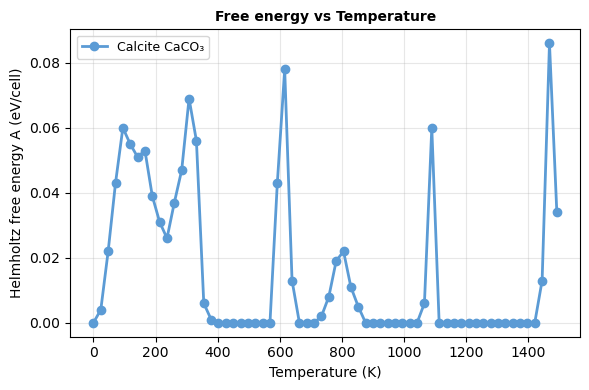

A(0 K)   = 0.0000 eV/cell
A(300 K) = ? eV/cell


In [45]:
# ── Parse Helmholtz free energy A(T) ──────────────────────────────────────
if text_phon:
    fe_data = []
    in_block = False
    for line in text_phon.split('\n'):
        if re.search(r'Helmholtz|Free energy.*temp', line, re.I):
            in_block = True; continue
        if in_block:
            nums = re.findall(r'-?[\d]+\.[\d]+', line)
            if len(nums) >= 2:
                try:
                    T, A = float(nums[0]), float(nums[-1])
                    if 0 <= T <= 2000: fe_data.append((T, A))
                except: pass
            elif in_block and re.match(r'\s*\*+', line):
                in_block = False

    if fe_data:
        Ts, As = zip(*fe_data)
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(Ts, As, 'o-', color='#5b9bd5', lw=2, label='Calcite CaCO₃')
        ax.set_xlabel('Temperature (K)', fontsize=10)
        ax.set_ylabel('Helmholtz free energy A (eV/cell)', fontsize=10)
        ax.set_title('Free energy vs Temperature', fontsize=10, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('ex2_free_energy.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"A(0 K)   = {As[0]:.4f} eV/cell")
        print(f"A(300 K) = {next((a for t,a in fe_data if abs(t-300)<1), '?')} eV/cell")
    else:
        print("Free energy table not found — search 'Helmholtz' in .gout")

---
## Exercise 3 · Elastic Constants, Moduli, and Seismic Velocities

**Goal:** Extract the full elastic constant tensor from your GULP output and derive
quantities that connect atomistic simulation to **geophysics and rock mechanics**.

### Why elastic constants matter in geochemistry

When seismic waves travel through the Earth's crust, their speed depends on the
**elastic stiffness** and **density** of the minerals they pass through.
Calcite-dominated limestones, dolomite, and magnesite marble all have different
seismic signatures — the elastic constants you calculate here are what underpins
those differences.

### The elastic constant tensor C_ij

For a crystal, the stress–strain relationship is:

$$\sigma_i = \sum_j C_{ij}\, \varepsilon_j$$

The 6×6 matrix **C** (in Voigt notation) is symmetric and, for trigonal minerals
like calcite, has the form:

$$\mathbf{C} = \begin{pmatrix}
C_{11} & C_{12} & C_{13} & C_{14} & 0 & 0 \\
C_{12} & C_{11} & C_{13} & -C_{14} & 0 & 0 \\
C_{13} & C_{13} & C_{33} & 0 & 0 & 0 \\
C_{14} & -C_{14} & 0 & C_{44} & 0 & 0 \\
0 & 0 & 0 & 0 & C_{44} & C_{14} \\
0 & 0 & 0 & 0 & C_{14} & \frac{1}{2}(C_{11}-C_{12})
\end{pmatrix}$$

### Derived moduli (Voigt–Reuss–Hill average)

GULP reports the **VRH averages**, which bracket the true polycrystalline behaviour
between the stiff (Voigt) and compliant (Reuss) limits:

| Quantity | Formula | Physical meaning |
|----------|---------|-----------------|
| Bulk modulus *K* | VRH avg. | Resistance to uniform compression |
| Shear modulus *G* | VRH avg. | Resistance to shear deformation |
| Young's modulus *E* | 9KG/(3K+G) | Resistance to uniaxial stretch |
| Poisson's ratio *ν* | (3K−2G)/(6K+2G) | Lateral contraction under load |

### Seismic wave velocities

$$V_P = \sqrt{\frac{K + \frac{4}{3}G}{\rho}} \qquad V_S = \sqrt{\frac{G}{\rho}}$$

where ρ is the crystal density (mass/volume). GULP computes these directly.

**No new input file is needed** — the `elas` keyword was already included in
`calcite.gin`, `magnesite.gin`, and `dolomite.gin` from Exercise 1.
Just use the same `.gout` files you already downloaded.

In [15]:
# ── Parse elastic constants from Exercise 1 output files ─────────────────────
import re, os, numpy as np
import matplotlib.pyplot as plt

def parse_elastic_matrix(text):
    """Extract 6x6 Cij matrix (GPa) from GULP output."""
    m = re.search(r'Elastic Constant Matrix.*?\n[-\s]+\n.*?\n(.*?)(?=\n\s*\n|Elastic Compliance)',
                  text, re.S)
    if not m:
        return None
    C = np.zeros((6, 6))
    rows = [l for l in m.group(1).split('\n') if re.search(r'^\s+[1-6]', l)]
    for row in rows:
        nums = re.findall(r'-?[\d]+\.[\d]+', row)
        i_match = re.match(r'\s+(\d)', row)
        if i_match and len(nums) >= 6:
            i = int(i_match.group(1)) - 1
            C[i, :] = [float(x) for x in nums[:6]]
    # symmetrise
    C = (C + C.T) / 2
    return C if np.any(C != 0) else None

def parse_moduli(text):
    """Return dict with K, G, E, nu — Hill (3rd) column from Mechanical properties block.
    GULP format: Bulk  Modulus (GPa)  =  <Reuss>  <Voigt>  <Hill>"""
    out = {}
    # Bulk modulus — Hill = group 3
    m = re.search(r'Bulk\s+Modulus\s*\(GPa\)\s*=\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', text)
    if m: out['K'] = float(m.group(3))
    # Shear modulus — Hill = group 3
    m = re.search(r'Shear Modulus\s*\(GPa\)\s*=\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', text)
    if m: out['G'] = float(m.group(3))
    # Young's moduli (x, y, z axes) — average the three
    m = re.search(r'Youngs Moduli\s*\(GPa\)\s*=\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', text)
    if m: out['E'] = (float(m.group(1)) + float(m.group(2)) + float(m.group(3))) / 3
    # Poisson's ratio — collect all numbers from Poissons Ratio lines and average
    nu_blocks = re.findall(r'Poissons Ratio.*?=([ \d.]+)', text)
    all_nu = [float(v) for block in nu_blocks for v in re.findall(r'[\d.]+', block)]
    if all_nu: out['nu'] = sum(all_nu) / len(all_nu)
    return out

def parse_velocities(text):
    """Return (V_P, V_S) in km/s — Hill (3rd) column.
    GULP format: Velocity P-wave (km/s)  =  <Reuss>  <Voigt>  <Hill>"""
    vp = vs = None
    m = re.search(r'Velocity\s+P-wave\s*\(km/s\)\s*=\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', text)
    if m: vp = float(m.group(3))
    m = re.search(r'Velocity\s+S-wave\s*\(km/s\)\s*=\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', text)
    if m: vs = float(m.group(3))
    return vp, vs

# ── Load files (reuse from Exercise 1) ────────────────────────────────────────
minerals = ['Calcite', 'Magnesite', 'Dolomite']
gouts    = ['calcite.gout', 'magnesite.gout', 'dolomite.gout']
texts    = []
for fn in gouts:
    if os.path.exists(fn):
        texts.append(open(fn).read())
    else:
        print(f"  {fn} not found — run Exercise 1 first")
        texts.append("")

# ── Print results ─────────────────────────────────────────────────────────────
print(f"{'':14s}  {'Calcite':>12s}  {'Magnesite':>12s}  {'Dolomite':>12s}")
print("─" * 58)

moduli_all = []
vels_all   = []
for txt in texts:
    moduli_all.append(parse_moduli(txt) if txt else {})
    vels_all.append(parse_velocities(txt) if txt else (None, None))

def row(label, vals):
    print(f"{label:14s}  " + "  ".join(f"{v:>12}" for v in vals))

for key, label, unit in [
    ('K',  'K_VRH',   'GPa'),
    ('G',  'G_VRH',   'GPa'),
    ('E',  'E (Young)', 'GPa'),
    ('nu', 'ν (Poisson)', ''),
]:
    vals = []
    for m in moduli_all:
        v = m.get(key)
        vals.append(f"{v:.3f}" if v is not None else '—')
    row(f"{label} ({unit})" if unit else label, vals)

print("─" * 58)
# Experimental reference moduli
expt_K = [73, 107, 94]
expt_G = [32, 58, 45]
row("K_expt (GPa)",  [str(v) for v in expt_K])
row("G_expt (GPa)",  [str(v) for v in expt_G])
print("─" * 58)

for i, (mineral, (vp, vs)) in enumerate(zip(minerals, vels_all)):
    vp_str = f"{vp:.3f}" if vp else "—"
    vs_str = f"{vs:.3f}" if vs else "—"
    print(f"  {mineral:12s}  V_P = {vp_str:>7s} km/s    V_S = {vs_str:>7s} km/s")

                     Calcite     Magnesite      Dolomite
──────────────────────────────────────────────────────────
K_VRH (GPa)           80.973       123.787        92.079
G_VRH (GPa)           31.833        57.563        39.327
E (Young) (GPa)        72.778       157.139       119.776
ν (Poisson)            0.369         0.298         0.290
──────────────────────────────────────────────────────────
K_expt (GPa)              73           107            94
G_expt (GPa)              32            58            45
──────────────────────────────────────────────────────────
  Calcite       V_P =   6.738 km/s    V_S =   3.422 km/s
  Magnesite     V_P =   8.161 km/s    V_S =   4.372 km/s
  Dolomite      V_P =   7.086 km/s    V_S =   3.696 km/s


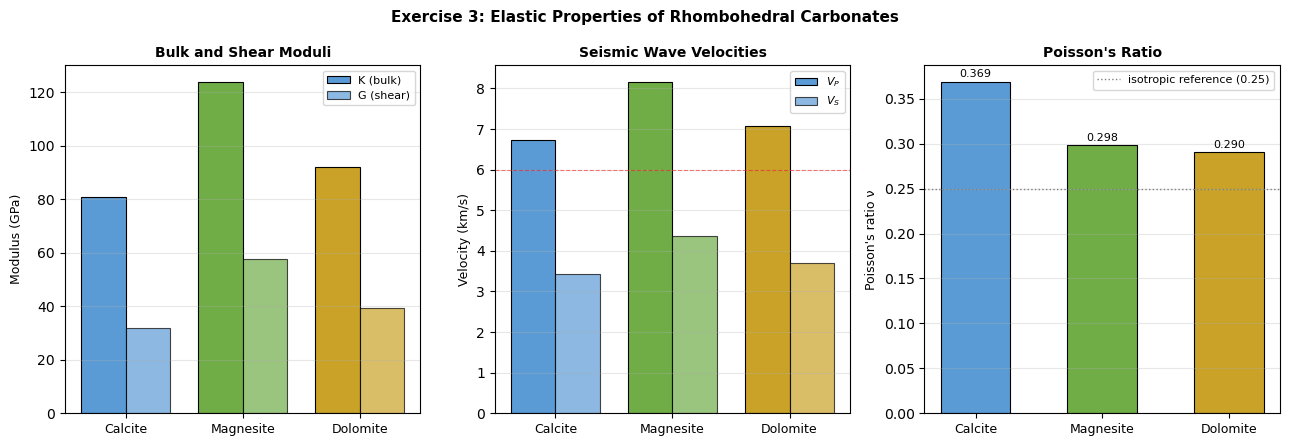

In [16]:
# ── Plot elastic moduli and seismic velocities ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
colors = ['#5b9bd5', '#70ad47', '#c9a227']
x = np.arange(len(minerals))
w = 0.38

# — Bulk and shear moduli
ax = axes[0]
K_vals = [moduli_all[i].get('K', 0) for i in range(3)]
G_vals = [moduli_all[i].get('G', 0) for i in range(3)]
b1 = ax.bar(x - w/2, K_vals, w, label='K (bulk)', color=colors, edgecolor='k', lw=0.8)
b2 = ax.bar(x + w/2, G_vals, w, label='G (shear)',
            color=[c + '99' for c in ['#5b9bd5','#70ad47','#c9a227']],
            edgecolor='k', lw=0.8, alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(minerals, fontsize=9)
ax.set_ylabel('Modulus (GPa)', fontsize=9)
ax.set_title('Bulk and Shear Moduli', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# — Seismic velocities
ax = axes[1]
vp_vals = [v[0] or 0 for v in vels_all]
vs_vals = [v[1] or 0 for v in vels_all]
ax.bar(x - w/2, vp_vals, w, label='$V_P$', color=colors, edgecolor='k', lw=0.8)
ax.bar(x + w/2, vs_vals, w, label='$V_S$',
       color=[c + '99' for c in ['#5b9bd5','#70ad47','#c9a227']],
       edgecolor='k', lw=0.8, alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(minerals, fontsize=9)
ax.set_ylabel('Velocity (km/s)', fontsize=9)
ax.set_title('Seismic Wave Velocities', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
# Reference lines: typical limestone V_P ~5-6 km/s, dolomite ~6-7 km/s
ax.axhline(6.0, color='red', lw=0.8, ls='--', alpha=0.5, label='typical crustal V_P')

# — Poisson ratio
ax = axes[2]
nu_vals = [moduli_all[i].get('nu', 0) for i in range(3)]
bars = ax.bar(x, nu_vals, 0.55, color=colors, edgecolor='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(minerals, fontsize=9)
ax.set_ylabel("Poisson's ratio ν", fontsize=9)
ax.set_title("Poisson's Ratio", fontsize=10, fontweight='bold')
ax.axhline(0.25, color='gray', lw=1, ls=':', label='isotropic reference (0.25)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, nu_vals):
    if val:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Exercise 3: Elastic Properties of Rhombohedral Carbonates',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('ex3_elastic.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Display the C_ij tensor for each mineral ──────────────────────────────────
import pandas as pd

for mineral, txt in zip(minerals, texts):
    if not txt:
        print(f"\n{mineral}: output not loaded"); continue
    C = parse_elastic_matrix(txt)
    if C is None or not np.any(C):
        print(f"\n{mineral}: elastic matrix not found in .gout")
        print("  (Check that the 'elas' keyword was present in the .gin file)")
        continue
    print(f"\n{'─'*62}")
    print(f"  {mineral}  —  Elastic constant tensor C_ij (GPa)")
    print(f"{'─'*62}")
    labels = ['C_11','C_12','C_13','C_14','C_15','C_16']
    df = pd.DataFrame(C, index=[f'  {i+1}' for i in range(6)],
                      columns=[f'   {i+1}' for i in range(6)])
    with pd.option_context('display.float_format', '{:8.2f}'.format,
                           'display.colheader_justify', 'right'):
        print(df.to_string())
    print()
    # Print the key independent elements for trigonal (D3d) symmetry
    print(f"  Independent elements: C11={C[0,0]:.1f}  C12={C[0,1]:.1f}  C13={C[0,2]:.1f}")
    print(f"                        C14={C[0,3]:.1f}  C33={C[2,2]:.1f}  C44={C[3,3]:.1f}")


──────────────────────────────────────────────────────────────
  Calcite  —  Elastic constant tensor C_ij (GPa)
──────────────────────────────────────────────────────────────
         1        2        3        4        5        6
1   150.59    65.07    61.97    19.84    -0.00    -0.00
2    65.07   150.59    61.97   -19.84     0.00    -0.00
3    61.97    61.97    84.52     0.00    -0.00    -0.00
4    19.84   -19.84     0.00    36.77    -0.00     0.00
5    -0.00     0.00    -0.00    -0.00    36.77    19.84
6    -0.00    -0.00    -0.00     0.00    19.84    42.76

  Independent elements: C11=150.6  C12=65.1  C13=62.0
                        C14=19.8  C33=84.5  C44=36.8

──────────────────────────────────────────────────────────────
  Magnesite  —  Elastic constant tensor C_ij (GPa)
──────────────────────────────────────────────────────────────
         1        2        3        4        5        6
1   247.81    93.28    77.76    23.91     0.00     0.00
2    93.28   247.81    77.76   -23

### Geophysical interpretation

**V_P / V_S ratio** is used in seismic surveys to discriminate between rock types
and to detect fluids. Carbonate reservoirs (limestone, dolomite) have characteristic
V_P/V_S signatures:

| Mineral | Typical V_P (km/s) | Typical V_S (km/s) | V_P/V_S |
|---------|-------------------|-------------------|---------|
| Calcite (limestone) | 6.6 | 3.4 | ~1.9 |
| Dolomite | 7.3 | 3.8 | ~1.9 |
| Magnesite | 7.7 | 4.5 | ~1.7 |

The **Poisson's ratio** ν is closely related to V_P/V_S:

$$\frac{V_P}{V_S} = \sqrt{\frac{2(1-\nu)}{1-2\nu}}$$

**Discussion questions:**
1. How do your computed seismic velocities compare to the tabulated values above?
   What is the % error?
2. Dolomite has both Ca and Mg — is its bulk modulus simply the average of
   calcite and magnesite? Why or why not?
3. The C_14 element (non-zero in trigonal symmetry) couples compressive and
   shear deformation. Is C_14 larger for calcite or magnesite? What does this
   imply for the anisotropy of seismic wave propagation?
4. In carbonate reservoir rocks, dolomitisation (replacement of calcite by dolomite)
   increases the bulk modulus. How would this appear on a seismic section?

---
## Exercise 4 · Thermodynamic Stability — Free Energy vs Temperature

**Goal:** Compute the Helmholtz free energy A(T) for **all three minerals** across
geological temperature ranges and compare their thermodynamic stability.

### Background

To obtain A(T) from GULP we need vibrational (phonon) frequencies.
Exercise 2 did this for calcite only — here we run dedicated phonon calculations
for **magnesite** and **dolomite** as well, using the relaxed structures from
Exercise 1 as starting points.

The free energy in the harmonic approximation is:

$$A(T) = U_{\text{static}} + E_{\text{ZPE}} - T\,S_{\text{vib}}$$

where:
- $U_{\text{static}}$ — total lattice energy from the geometry optimisation
- $E_{\text{ZPE}} = \frac{1}{2}\sum_k \hbar\omega_k$ — zero-point energy
- $S_{\text{vib}}$ — vibrational entropy from the phonon density of states

The `temperature 0 1000 100` keyword tells GULP to evaluate A(T) at
0, 100, 200, …, 1000 K.

### New input files for this exercise

The three `.gin` files below are identical to the Exercise 1 inputs **except**
that we start from the relaxed structure (via `restart`) and only request
the phonon and free energy calculation — no further geometry optimisation.
Save each file and submit to the cluster exactly as in Exercise 1.

**Expected run time:** < 2 min per mineral on granado.

---
### Exercise 4 input files

Three phonon `.gin` files are needed — one per mineral.
`calcite_phonon.gin` was already prepared in Exercise 2.
Save the two new files below and upload all three to the cluster.

In [18]:
magnesite_phonon_gin = '''phon comp mole

# Magnesite phonon — starts from relaxed Exercise 1 structure

name magnesite_phonon

pressure 0.0 GPa

cell
4.990000 4.990000 17.002000  90.000000 90.000000 120.000000
fractional
Mg   core     0.000000    0.000000    0.000000    1.0000000
C1   core     0.000000    0.000000    0.250000    1.0000000
O1   core     0.257060    0.000000    0.250000    1.0000000
O1   core     0.000000    0.257060    0.250000    1.0000000
O1   core    -0.257060   -0.257060    0.250000    1.0000000
Mg   core     0.000000    0.000000    0.500000    1.0000000
C1   core     0.000000    0.000000    0.750000    1.0000000
O1   core    -0.257060    0.000000    0.750000    1.0000000
O1   core     0.000000   -0.257060    0.750000    1.0000000
O1   core     0.257060    0.257060    0.750000    1.0000000
Mg   core     0.666667    0.333333    0.333333    1.0000000
C1   core     0.666667    0.333333    0.583333    1.0000000
O1   core     0.923727    0.333333    0.583333    1.0000000
O1   core     0.666667    0.590393    0.583333    1.0000000
O1   core     0.409607    0.076273    0.583333    1.0000000
Mg   core     0.666667    0.333333    0.833333    1.0000000
C1   core     0.666667    0.333333    0.083333    1.0000000
O1   core     0.409607    0.333333    0.083333    1.0000000
O1   core     0.666667    0.076273    0.083333    1.0000000
O1   core     0.923727    0.590393    0.083333    1.0000000
Mg   core     0.333333    0.666667    0.666667    1.0000000
C1   core     0.333333    0.666667    0.916667    1.0000000
O1   core     0.590393    0.666667    0.916667    1.0000000
O1   core     0.333333    0.923727    0.916667    1.0000000
O1   core     0.076273    0.409607    0.916667    1.0000000
Mg   core     0.333333    0.666667    0.166667    1.0000000
C1   core     0.333333    0.666667    0.416667    1.0000000
O1   core     0.076273    0.666667    0.416667    1.0000000
O1   core     0.333333    0.409607    0.416667    1.0000000
O1   core     0.590393    0.923727    0.416667    1.0000000
O1   shel     0.590393    0.923727    0.416667    1.0000000
O1   shel     0.333333    0.409607    0.416667    1.0000000
O1   shel     0.076273    0.666667    0.416667    1.0000000
O1   shel     0.076273    0.409607    0.916667    1.0000000
O1   shel     0.333333    0.923727    0.916667    1.0000000
O1   shel     0.590393    0.666667    0.916667    1.0000000
O1   shel     0.923727    0.590393    0.083333    1.0000000
O1   shel     0.666667    0.076273    0.083333    1.0000000
O1   shel     0.409607    0.333333    0.083333    1.0000000
O1   shel     0.409607    0.076273    0.583333    1.0000000
O1   shel     0.666667    0.590393    0.583333    1.0000000
O1   shel     0.923727    0.333333    0.583333    1.0000000
O1   shel     0.257060    0.257060    0.750000    1.0000000
O1   shel     0.000000   -0.257060    0.750000    1.0000000
O1   shel    -0.257060    0.000000    0.750000    1.0000000
O1   shel    -0.257060   -0.257060    0.250000    1.0000000
O1   shel     0.000000    0.257060    0.250000    1.0000000
O1   shel     0.257060    0.000000    0.250000    1.0000000

space
P 1

species 4
Mg core 2.00000
C  core 1.343539
O  core 1.018487
O  shel -2.133
end

shrink 4

buck
Mg  core  O   shel   1039.59    0.2893        0.0000  0.00    10.0
buck
Mg  core  C   core  26164795.4  0.120000  0.000000    0.00 10.00
buck intra
O     core O     core    4030.300     0.245497   0.0000       0.00   2.50
buck inter
O     shel O     shel  64242.4540     0.198913  21.8436       0.00  15.0
morse intra bond
C core O core  5.000   2.5228   1.19820  0.00
spring
O  52.7400
three  bond intra regular
C core O core O core  1.7995  120.00
outofplane bond intra
C cor  O  cor  O cor O cor     8.6892     360.0

temperature 0 1000 100

output freq text magnesite_freq.dat
dump   magnesite_phonon.res
'''
with open("magnesite_phonon.gin", "w") as f:
    f.write(magnesite_phonon_gin)
print("Saved: magnesite_phonon.gin")

Saved: magnesite_phonon.gin


In [19]:
dolomite_phonon_gin = '''phon comp mole

# Dolomite phonon — starts from relaxed Exercise 1 structure

name dolomite_phonon

cell
  11.977695  12.009314   6.004657  46.977393  47.347616  47.346984

fractional  1
Ca    core 0.5000000 0.0000000 0.0000000 2.00000000 1.00000 0.00000
Ca    core 0.5000367 0.5000158 0.9999521 2.00000000 1.00000 0.00000
Ca    core 0.7693350 0.2402966 0.4806526 2.00000000 1.00000 0.00000
Ca    core 0.7693513 0.7403219 0.4805755 2.00000000 1.00000 0.00000
C     core 0.6346920 0.1181236 0.2443659 1.34353899 1.00000 0.00000
C     core 0.6347006 0.6181089 0.2443381 1.34353899 1.00000 0.00000
C     core 0.1346823 0.1101642 0.2602895 1.34353899 1.00000 0.00000
C     core 0.1346939 0.6101705 0.2602707 1.34353899 1.00000 0.00000
C     core 0.8964609 0.8561055 0.7398020 1.34353899 1.00000 0.00000
C     core 0.8964524 0.3561082 0.7398195 1.34353899 1.00000 0.00000
C     core 0.3729291 0.8703885 0.7684337 1.34353899 1.00000 0.00000
C     core 0.3729247 0.3703890 0.7684036 1.34353899 1.00000 0.00000
O     core 0.7712322 0.9955451 0.2561584 1.01848700 1.00000 0.00000
O     core 0.7712411 0.4955289 0.2561207 1.01848700 1.00000 0.00000
O     core 0.2565972 0.9731659 0.2600974 1.01848700 1.00000 0.00000
O     core 0.2566251 0.4731850 0.2600445 1.01848700 1.00000 0.00000
O     core 0.1346995 0.7421481 0.9963012 1.01848700 1.00000 0.00000
O     core 0.1347188 0.2421347 0.9963063 1.01848700 1.00000 0.00000
O     core 0.6346920 0.7490481 0.9825041 1.01848700 1.00000 0.00000
O     core 0.6346875 0.2490581 0.9825209 1.01848700 1.00000 0.00000
O     core 0.0127467 0.1102989 0.5342484 1.01848700 1.00000 0.00000
O     core 0.0127617 0.6102796 0.5342405 1.01848700 1.00000 0.00000
O     core 0.4981580 0.1122044 0.4895197 1.01848700 1.00000 0.00000
O     core 0.4981686 0.6121948 0.4895096 1.01848700 1.00000 0.00000
O     core 0.2508047 0.0080219 0.7335076 1.01848700 1.00000 0.00000
O     core 0.2508050 0.5080278 0.7334673 1.01848700 1.00000 0.00000
O     core 0.7616214 0.9787378 0.7867109 1.01848700 1.00000 0.00000
O     core 0.7616267 0.4787620 0.7866237 1.01848700 1.00000 0.00000
O     core 0.9104504 0.2163402 0.9834448 1.01848700 1.00000 0.00000
O     core 0.9105062 0.7163097 0.9833930 1.01848700 1.00000 0.00000
O     core 0.3589028 0.2485961 0.0479787 1.01848700 1.00000 0.00000
O     core 0.3589186 0.7485851 0.0479913 1.01848700 1.00000 0.00000
O     core 0.0185696 0.8735877 0.4645150 1.01848700 1.00000 0.00000
O     core 0.0185897 0.3735443 0.4645945 1.01848700 1.00000 0.00000
O     core 0.5077615 0.8469418 0.5231427 1.01848700 1.00000 0.00000
O     core 0.5077605 0.3469333 0.5231266 1.01848700 1.00000 0.00000
Mg    core 0.0186179 0.9868988 0.9932551 2.00000000 1.00000 0.00000
Mg    core 0.0186193 0.4868833 0.9932477 2.00000000 1.00000 0.00000
Mg    core 0.2507605 0.2436747 0.5068376 2.00000000 1.00000 0.00000
Mg    core 0.2507590 0.7436454 0.5068879 2.00000000 1.00000 0.00000
O     shel 0.7735190 0.9942156 0.2527276 -2.1330000 1.00000 0.00000
O     shel 0.7735278 0.4942005 0.2526956 -2.1330000 1.00000 0.00000
O     shel 0.2561676 0.9714804 0.2651137 -2.1330000 1.00000 0.00000
O     shel 0.2561911 0.4714996 0.2650610 -2.1330000 1.00000 0.00000
O     shel 0.1347016 0.7434886 0.9936110 -2.1330000 1.00000 0.00000
O     shel 0.1347210 0.2434779 0.9936183 -2.1330000 1.00000 0.00000
O     shel 0.6346909 0.7490111 0.9825802 -2.1330000 1.00000 0.00000
O     shel 0.6346882 0.2490189 0.9825948 -2.1330000 1.00000 0.00000
O     shel 0.0131817 0.1077871 0.5376253 -2.1330000 1.00000 0.00000
O     shel 0.0131963 0.6077680 0.5376157 -2.1330000 1.00000 0.00000
O     shel 0.4958703 0.1139175 0.4921823 -2.1330000 1.00000 0.00000
O     shel 0.4958806 0.6139099 0.4921725 -2.1330000 1.00000 0.00000
O     shel 0.2493958 0.0083482 0.7341224 -2.1330000 1.00000 0.00000
O     shel 0.2493974 0.5083562 0.7340853 -2.1330000 1.00000 0.00000
O     shel 0.7609950 0.9790828 0.7881313 -2.1330000 1.00000 0.00000
O     shel 0.7609958 0.4791079 0.7880487 -2.1330000 1.00000 0.00000
O     shel 0.9102395 0.2157850 0.9863615 -2.1330000 1.00000 0.00000
O     shel 0.9102932 0.7157543 0.9863119 -2.1330000 1.00000 0.00000
O     shel 0.3591153 0.2471366 0.0490872 -2.1330000 1.00000 0.00000
O     shel 0.3591338 0.7471229 0.0490940 -2.1330000 1.00000 0.00000
O     shel 0.0199752 0.8732777 0.4638670 -2.1330000 1.00000 0.00000
O     shel 0.0199997 0.3732327 0.4639459 -2.1330000 1.00000 0.00000
O     shel 0.5083894 0.8462295 0.5224516 -2.1330000 1.00000 0.00000
O     shel 0.5083891 0.3462231 0.5224389 -2.1330000 1.00000 0.00000

shrink   4

species   5
Ca     core    2.000000
Mg     core    2.000000
C      core    1.343539
O      core    1.018487
O      shel   -2.133000
end

element
cova Mg 0.0
end

Pressure 0.0 GPa

buck
C     core Ca    core  1.2E8     0.120000  0.000000      0.00 10.00
buck
Ca    core O     shel  2154.00000     0.289118  0.000000      0.00 10.00
buck
Mg    core O     shel  1039.59000     0.289300  0.000000      0.00 10.00
buck intra
O     core O     core  4030.30000     0.245497  0.000000      0.00  2.50
buck inter
O     shel O     shel  64242.4540     0.198913  21.84360      0.00 15.00
morse intra bond
C     core O     core 5.0000000     2.5228      1.19820  0.0000
spring
O      52.740000
three bond intra regular
C     core O     core O     core 1.7995     120.00
outofplane bond intra
C     cor O     cor O     cor O     cor   8.6892       360.00

temperature 0 1000 100

output freq text dolomite_freq.dat
dump   dolomite_phonon.res
'''
with open("dolomite_phonon.gin", "w") as f:
    f.write(dolomite_phonon_gin)
print("Saved: dolomite_phonon.gin")

Saved: dolomite_phonon.gin


### Submitting Exercise 4 to the cluster

Upload `calcite_phonon.gin`, `magnesite_phonon.gin`, and `dolomite_phonon.gin`
to `~/gulp_tutorial/` on granado, then submit:

```bash
# Re-use and adapt run_calcite.sh
cp run_calcite.sh run_calcite_phonon.sh
sed -i 's/calcite.gin/calcite_phonon.gin/; s/calcite.gout/calcite_phonon.gout/' run_calcite_phonon.sh
sbatch run_calcite_phonon.sh

cp run_magnesite.sh run_magnesite_phonon.sh
sed -i 's/magnesite.gin/magnesite_phonon.gin/; s/magnesite.gout/magnesite_phonon.gout/' run_magnesite_phonon.sh
sbatch run_magnesite_phonon.sh

cp run_dolomite.sh run_dolomite_phonon.sh
sed -i 's/dolomite.gin/dolomite_phonon.gin/; s/dolomite.gout/dolomite_phonon.gout/' run_dolomite_phonon.sh
sbatch run_dolomite_phonon.sh
```

Download when complete:
```bash
scp your_username@granado.uninorte.edu.co:~/gulp_tutorial/*_phonon.gout .
```

### Exercise 4 — Free Energy Analysis

Run the cell below once you have `calcite_phonon.gout`, `magnesite_phonon.gout`,
and `dolomite_phonon.gout` in the same folder as this notebook.

In [22]:
import re, numpy as np
import matplotlib.pyplot as plt

def parse_free_energy(filepath, T_max=5000):
    """
    Parse GULP phonon .gout file.
    
    El formato real es bloques repetidos, uno por temperatura:
      Phonon properties ...: Temperature = XXX.XXX K
      ----
      Zero point energy  = XXX eV        ← siempre presente
      Helmholtz free-energy = XXX eV     ← ausente en T=0 K
      
    A T=0 K GULP no imprime la línea Helmholtz, solo ZPE.
    """
    data = []
    current_T = None
    with open(filepath) as f:
        for line in f:
            # 1) Detectar encabezado de bloque con la temperatura
            m = re.search(r'Phonon properties.*Temperature\s*=\s*([\d.]+)\s*K', line)
            if m:
                current_T = float(m.group(1))
                continue
            # 2) Dentro del bloque, buscar la línea Helmholtz (solo la de eV, no kJmol)
            if current_T is not None and current_T <= T_max:
                if 'Helmholtz free-energy' in line:
                    m2 = re.search(r'=\s*(-?[\d]+\.[\d]+)\s*eV', line)
                    if m2:
                        A = float(m2.group(1))
                        data.append((current_T, A))
                        current_T = None   # bloque consumido, esperar el siguiente
    return sorted(data)

# ── Cargar datos ──────────────────────────────────────────────────────────────
phon_files = {
    'Calcite':   'calcite_phonon.gout',
    'Magnesite': 'magnesite_phonon.gout',
    'Dolomite':  'dolomite_phonon.gout',
}

T_MAX = 5000   # K — ajusta según el rango geológico que necesites

fe_all = {}
for mineral, fn in phon_files.items():
    if not os.path.exists(fn):
        print(f"  {mineral}: {fn} no encontrado")
        continue
    fe = parse_free_energy(fn, T_max=T_MAX)
    if fe:
        fe_all[mineral] = fe
        print(f"  {mineral}: {len(fe)} puntos, "
              f"A({fe[0][0]:.0f}K) = {fe[0][1]:.4f} eV,  "
              f"A({fe[-1][0]:.0f}K) = {fe[-1][1]:.4f} eV")
    else:
        print(f"  {mineral}: tabla de energía libre no encontrada")

  Calcite: 5 puntos, A(1000K) = -260.6128 eV,  A(5000K) = -344.0188 eV
  Magnesite: 5 puntos, A(1000K) = -271.2779 eV,  A(5000K) = -342.7571 eV
  Dolomite: 5 puntos, A(1000K) = -357.8115 eV,  A(5000K) = -465.8987 eV


  Calcite: 5 puntos, A(1000K) = -43.4355 eV/fu,  A(5000K) = -57.3365 eV/fu
  Magnesite: 5 puntos, A(1000K) = -45.2130 eV/fu,  A(5000K) = -57.1262 eV/fu
  Dolomite: 5 puntos, A(1000K) = -44.7264 eV/fu,  A(5000K) = -58.2373 eV/fu


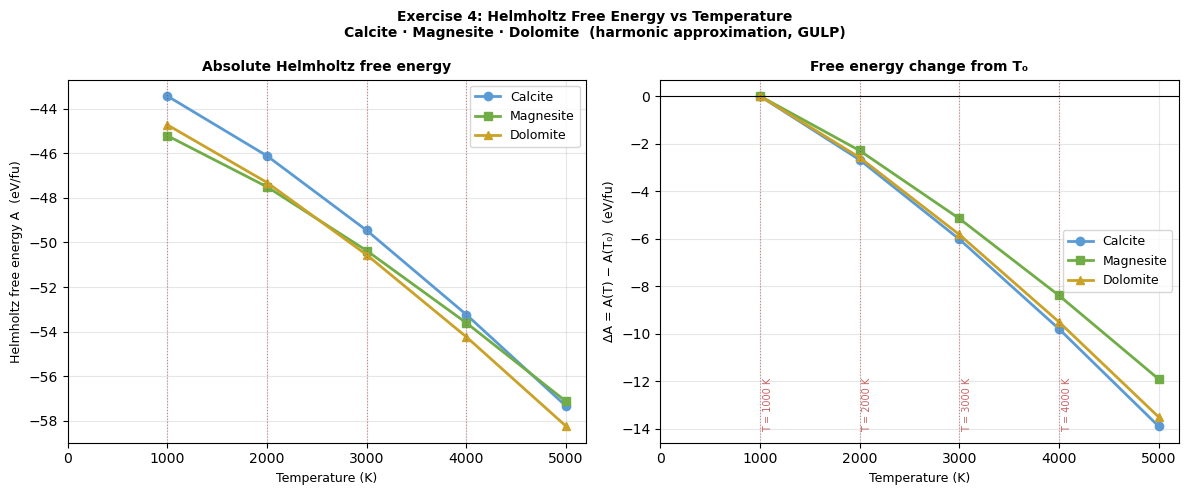


A(T) decreases with T because of the −T·S_vib entropy term.
The slope |dA/dT| = S is larger for phases with softer (lower-frequency) phonons.


In [29]:
import re, os, numpy as np
import matplotlib.pyplot as plt

# ── Parser ────────────────────────────────────────────────────────────────────
def parse_free_energy(filepath, T_max=5000):
    """
    Parse GULP phonon .gout: bloques repetidos con
      Phonon properties...: Temperature = XXX.XXX K
      Helmholtz free-energy = XXX eV   (ausente en T=0 K)
    """
    data = []
    current_T = None
    with open(filepath) as f:
        for line in f:
            m = re.search(r'Phonon properties.*Temperature\s*=\s*([\d.]+)\s*K', line)
            if m:
                current_T = float(m.group(1))
                continue
            if current_T is not None and current_T <= T_max:
                if 'Helmholtz free-energy' in line:
                    m2 = re.search(r'=\s*(-?[\d]+\.[\d]+)\s*eV', line)
                    if m2:
                        data.append((current_T, float(m2.group(1))))
                        current_T = None
    return sorted(data)

# ── Cargar datos ──────────────────────────────────────────────────────────────
phon_files = {
    'Calcite':   'calcite_phonon.gout',
    'Magnesite': 'magnesite_phonon.gout',
    'Dolomite':  'dolomite_phonon.gout',
}

# Unidades de fórmula por celda (verificado en .gout):
#   Calcite:   Ca6C6O18      → 6 x CaCO3
#   Magnesite: Mg6C6O18      → 6 x MgCO3
#   Dolomite:  Ca4Mg4C8O24   → 4 x CaMg(CO3)2
fu = {'Calcite': 6, 'Magnesite': 6, 'Dolomite': 8}

T_MAX = 5000  # K

fe_all = {}
for mineral, fn in phon_files.items():
    if not os.path.exists(fn):
        print(f"  {mineral}: {fn} no encontrado")
        continue
    fe = parse_free_energy(fn, T_max=T_MAX)
    if fe:
        fe_all[mineral] = fe
        print(f"  {mineral}: {len(fe)} puntos, "
              f"A({fe[0][0]:.0f}K) = {fe[0][1]/fu[mineral]:.4f} eV/fu,  "
              f"A({fe[-1][0]:.0f}K) = {fe[-1][1]/fu[mineral]:.4f} eV/fu")
    else:
        print(f"  {mineral}: tabla de energía libre no encontrada")

# ── Plot ──────────────────────────────────────────────────────────────────────
if fe_all:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    col    = {'Calcite': '#5b9bd5', 'Magnesite': '#70ad47', 'Dolomite': '#c9a227'}
    marker = {'Calcite': 'o',       'Magnesite': 's',        'Dolomite': '^'}

    for mineral, data in fe_all.items():
        Ts = np.array([d[0] for d in data])
        As = np.array([d[1] for d in data]) / fu[mineral]  # eV per formula unit
        ax1.plot(Ts, As,         marker[mineral]+'-', color=col[mineral], lw=2, ms=6, label=mineral)
        ax2.plot(Ts, As - As[0], marker[mineral]+'-', color=col[mineral], lw=2, ms=6, label=mineral)

    # Referencias — a temperaturas con datos reales (paso = 1000 K)
    geo_refs = [(1000, 'T = 1000 K'), (2000, 'T = 2000 K'),
                (3000, 'T = 3000 K'), (4000, 'T = 4000 K')]
    for T_ref, label in geo_refs:
        for ax in [ax1, ax2]:
            ax.axvline(T_ref, color='firebrick', lw=0.8, ls=':', alpha=0.5)

    for ax, ylabel, title in [
        (ax1, 'Helmholtz free energy A  (eV/fu)',  'Absolute Helmholtz free energy'),
        (ax2, 'ΔA = A(T) − A(T₀)  (eV/fu)',        'Free energy change from T₀'),
    ]:
        ax.set_xlabel('Temperature (K)', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        ax.set_xlim(left=0)

    ax2.axhline(0, color='k', lw=0.8)

    # Etiquetas — después de canvas.draw() para tener ylim real
    fig.canvas.draw()
    for T_ref, label in geo_refs:
        ylim = ax2.get_ylim()
        ax2.text(T_ref + 30, ylim[0] + 0.03*(ylim[1] - ylim[0]),
                 label, fontsize=7, rotation=90,
                 color='firebrick', alpha=0.7, va='bottom')

    fig.suptitle(
        'Exercise 4: Helmholtz Free Energy vs Temperature\n'
        'Calcite · Magnesite · Dolomite  (harmonic approximation, GULP)',
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('ex4_free_energy.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nA(T) decreases with T because of the −T·S_vib entropy term.")
    print("The slope |dA/dT| = S is larger for phases with softer (lower-frequency) phonons.")

### Geological context for the free energy results

The relative stability of carbonate phases at geological *P–T* conditions controls
key diagenetic and metamorphic reactions:

| Reaction | Temperature | Setting |
|----------|-------------|---------|
| Dolomitisation: CaCO₃ + Mg²⁺ → CaMg(CO₃)₂ + Ca²⁺ | 50–200°C | Burial diagenesis |
| Calcite–aragonite transition | 300–400°C (high P) | Subduction |
| Decarbonation: CaCO₃ → CaO + CO₂ | >650°C | Contact metamorphism |
| Dolomite breakdown: CaMg(CO₃)₂ → CaO + MgO + 2CO₂ | >750°C | Granulite facies |

**Limitations of the harmonic free energy:**
- The calculation ignores **thermal expansion** (the cell volume is fixed at 0 K geometry)
- Anharmonic effects become significant above ~600 K for carbonates
- Phase transitions (e.g., calcite I → calcite II at ~1.5 GPa) are not captured
- Pressure is fixed at 0 GPa; real burial diagenesis occurs at 0.1–0.3 GPa

A more complete treatment would use **quasi-harmonic approximation** (QHA),
where you repeat the phonon calculation at several volumes and fit the
free energy surface G(P, T).

---
## Summary and Discussion Questions

### What you have simulated

| Exercise | System | Keywords | Main result |
|----------|--------|----------|-------------|
| 1 | Calcite, Magnesite, Dolomite | `opti conp mole comp elas` | Cell params, lattice energy, K |
| 2 | Calcite | `+ phonon + temperature` | Mode frequencies, A(T) |
| 3 | All three | `elas` (from Ex.1 output) | Full C_ij tensor, V_P, V_S |
| 4 | All three | `phon + temperature 0 1000 100` | Free energy A(T), geological stability |

### Key results to discuss

1. **Cell parameters:** How well does the force field reproduce the experimental
   *a* and *c* values? What is the % error?

2. **Bulk modulus trend:** Calcite (∼73 GPa) < Dolomite (∼94 GPa) < Magnesite (∼107 GPa).
   Can you explain this trend from the ionic radii and bond lengths?

3. **Seismic velocities:** Your computed V_P for calcite should be ~6.5–7.0 km/s.
   How does the Mg-for-Ca substitution change V_P? What would this look like
   on a seismic section passing through a dolomitised limestone?

4. **Dolomite as an intermediate:** Is the dolomite bulk modulus simply the
   average of calcite and magnesite? What does this tell you about how
   cation ordering affects mechanical properties?

5. **Phonon modes:** Identify the CO₃ internal modes (ν₁–ν₄) in your frequency
   list. Do they match the IR absorption bands reported in the literature for calcite?

6. **Free energy:** Does A(T) decrease or increase with temperature? Why?
   (Hint: consider the entropy term −TS.)
   Which mineral loses the most free energy per kelvin — and why?

### Further reading

- Gale, J.D. (2011) *EPJ Web of Conferences* **14**, 03005 — original tutorial
- Rohl, Wright & Gale (2003) *Am. Min.* **88**, 921 — CaCO₃ force field
- Fisler, Gale & Cygan (2000) *Am. Min.* **85**, 217 — shell model for rhombohedral carbonates
- GULP manual: [gulp.curtin.edu.au](https://gulp.curtin.edu.au)